# Per-cluster resolution policies — k-fold evaluation

Does routing each question to its own image resolution beat simply running every
question at one well-chosen fixed resolution?

**The bar is `lift`**: accuracy minus that of a *fixed* budget costing the same.
Beating "always full resolution" while spending less is not evidence — a cheaper
fixed budget usually does that too. Every number below is measured on documents
the clustering never saw: KMeans and the per-cluster budgets are fit on the
training folds and applied to the held-out fold.

Two benchmarks are evaluated side by side, using the sweeps under `benchmarks/`.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError("could not locate the project root")
    PROJECT_ROOT = PROJECT_ROOT.parent

# ── Sweeps to evaluate: label -> results directory ────────────────────────────
RUNS = {
    "seedbench_2_plus": PROJECT_ROOT / "benchmarks/seedbench_2_plus/Qwen-Qwen3.5-4B",
    "mmmu_pro_standard": PROJECT_ROOT / "benchmarks/mmmu_pro_standard/Qwen-Qwen3.5-4B-tok32k",
}

# ── Cross-validation ──────────────────────────────────────────────────────────
K_VALUES = [2, 3, 5, 8, 12, 20, 30, 50]
N_FOLDS = 5
RANDOM_STATE = 42

# K used for the single-K strategy comparison chart (section 5); must be in K_VALUES.
SUMMARY_K = 30

# ── Cost basis. input_tokens is what the model actually pays for; sent_px is
#    what the pipeline controls. Both are recorded per document per budget. ─────
COST = "input_tokens"

EMBEDDING_MODEL = "all-MiniLM-L6-v2"
RESULTS_DIR = PROJECT_ROOT / "src/clustering/results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer

from clustering.data import load_sweep, question_text
from clustering.kfold import cross_validate, fixed_frontier, lift

sns.set_style("whitegrid")
%matplotlib inline

encoder = SentenceTransformer(EMBEDDING_MODEL)

sweeps, embeddings = {}, {}
for label, run_dir in RUNS.items():
    sweep = load_sweep(run_dir, cost=COST)
    sweeps[label] = sweep
    embeddings[label] = encoder.encode(
        question_text(sweep.task, sweep.doc_ids), show_progress_bar=False, convert_to_numpy=True
    )
    print(f"{label}: {sweep.n_documents} documents x {len(sweep.budgets)} budgets")

C:\Users\Andrew\Msc\scale-wise-optimizer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1229.05it/s]

seedbench_2_plus: 2277 documents x 10 budgets


mmmu_pro_standard: 1730 documents x 10 budgets


---
## 1. The fixed-budget frontier

This is what routing has to beat. Each point is one budget applied to every
document, averaged over the held-out folds.

In [3]:
folds = {label: cross_validate(sweeps[label], embeddings[label], K_VALUES, N_FOLDS, RANDOM_STATE) for label in RUNS}

for label in RUNS:
    curve = fixed_frontier(folds[label])
    curve.insert(0, "benchmark", label)
    print(curve.to_string(index=False))
    print()

       benchmark   budget       cost  accuracy
seedbench_2_plus   2000.0 107.631487  0.470365
seedbench_2_plus  12500.0 115.631487  0.475193
seedbench_2_plus  25000.0 131.631487  0.492305
seedbench_2_plus  50000.0 155.631487  0.527881
seedbench_2_plus 100000.0 206.631487  0.595079
seedbench_2_plus 150000.0 250.631487  0.634166
seedbench_2_plus 250000.0 362.631487  0.679407
seedbench_2_plus 400000.0 506.631487  0.693457
seedbench_2_plus 600000.0 682.631487  0.706188
seedbench_2_plus 800000.0 731.631487  0.712347

        benchmark   budget       cost  accuracy
mmmu_pro_standard   2000.0 228.738728  0.258960
mmmu_pro_standard  12500.0 240.358382  0.324855
mmmu_pro_standard  25000.0 253.908671  0.363584
mmmu_pro_standard  50000.0 280.351445  0.408671
mmmu_pro_standard 100000.0 325.985549  0.432948
mmmu_pro_standard 150000.0 363.471098  0.445665
mmmu_pro_standard 250000.0 420.509249  0.431792
mmmu_pro_standard 400000.0 481.623121  0.437572
mmmu_pro_standard 600000.0 537.536994  0.438728
mm

---
## 2. Lift — the result that matters

`lift > 0` means routing beat a fixed budget of the same cost. `NaN` marks
policies cheaper than the cheapest fixed budget, where no comparison exists
rather than an extrapolated one.

In [4]:
lifts = {}
for label in RUNS:
    table = lift(folds[label])
    table.insert(0, "benchmark", label)
    lifts[label] = table
    best = table.dropna(subset=["lift"]).sort_values("lift", ascending=False)
    print(f"── {label} ── best lift by strategy")
    print(
        best.groupby("strategy")
        .head(1)[["strategy", "k", "accuracy", "fixed_at_same_cost", "lift", "cost_share"]]
        .round(4)
        .to_string(index=False)
    )
    print(f"   positive lift in {(table['lift'] > 0).sum()} of {table['lift'].notna().sum()} comparable settings")
    print()

all_lift = pd.concat(lifts.values(), ignore_index=True)
all_lift.to_csv(RESULTS_DIR / "kfold_lift.csv", index=False)
pd.concat(folds.values(), keys=folds, names=["benchmark", None]).reset_index(level=0).to_csv(
    RESULTS_DIR / "kfold_folds.csv", index=False
)

── seedbench_2_plus ── best lift by strategy
    strategy    k  accuracy  fixed_at_same_cost    lift  cost_share
efficient_95  3.0    0.6842              0.6853 -0.0010      0.5778
        best  2.0    0.7075              0.7114 -0.0039      0.9901
efficient_99 20.0    0.6956              0.7014 -0.0058      0.8430
   positive lift in 0 of 24 comparable settings

── mmmu_pro_standard ── best lift by strategy
    strategy   k  accuracy  fixed_at_same_cost    lift  cost_share
        best 5.0    0.4422              0.4398  0.0024      0.6743
efficient_99 5.0    0.4405              0.4418 -0.0014      0.6601
efficient_95 5.0    0.4277              0.4344 -0.0066      0.5747
   positive lift in 1 of 24 comparable settings



---
## 3. Lift against K

If routing worked, lift would be reliably positive across K rather than
flickering around zero.

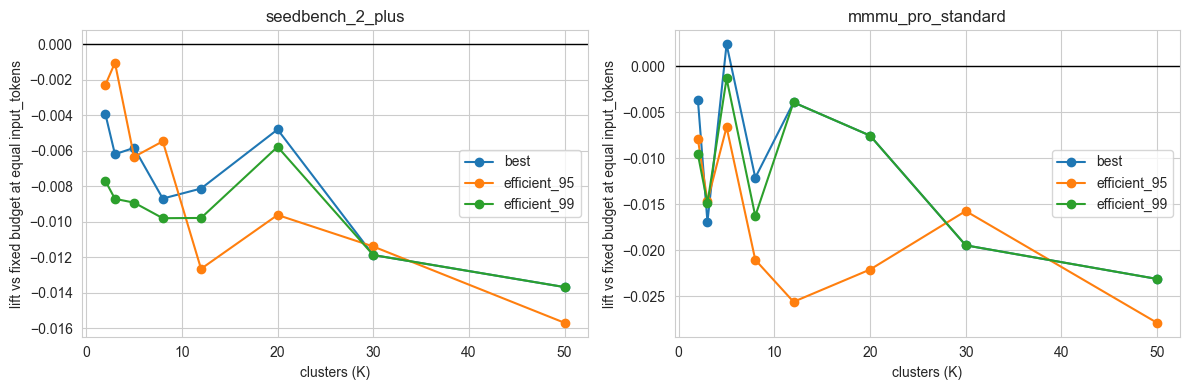

In [5]:
fig, axes = plt.subplots(1, len(RUNS), figsize=(6 * len(RUNS), 4), squeeze=False)
for ax, label in zip(axes[0], RUNS, strict=True):
    table = lifts[label]
    for strategy, group in table.groupby("strategy"):
        ax.plot(group["k"], group["lift"], marker="o", label=strategy)
    ax.axhline(0, color="black", lw=1)
    ax.set_title(label)
    ax.set_xlabel("clusters (K)")
    ax.set_ylabel(f"lift vs fixed budget at equal {COST}")
    ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "kfold_lift_vs_k.pdf")
plt.show()

---
## 4. Accuracy vs cost

The routed strategies are plotted against the fixed frontier. A strategy is only
interesting if it sits **above** the line, not merely to the left of the most
expensive point.

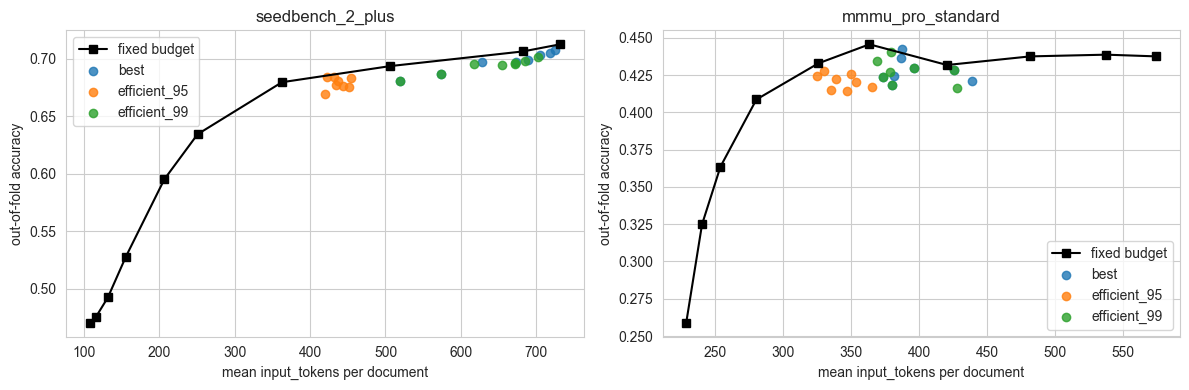

In [6]:
fig, axes = plt.subplots(1, len(RUNS), figsize=(6 * len(RUNS), 4), squeeze=False)
for ax, label in zip(axes[0], RUNS, strict=True):
    curve = fixed_frontier(folds[label])
    ax.plot(curve["cost"], curve["accuracy"], marker="s", color="black", label="fixed budget")
    table = lifts[label]
    for strategy, group in table.groupby("strategy"):
        ax.scatter(group["cost"], group["accuracy"], label=strategy, alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel(f"mean {COST} per document")
    ax.set_ylabel("out-of-fold accuracy")
    ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "kfold_accuracy_vs_cost.pdf")
plt.show()

---
## 5. Strategy comparison at a single K

The chart the original notebook produced, rebuilt on k-fold: accuracy against
relative cost, with error bars showing the spread across folds on **both** axes.
The routed strategies vary in cost between folds (different clusters get
different budgets), which the original's single split could not show.

In [7]:
from clustering.kfold import strategy_summary

summaries = {label: strategy_summary(folds[label], SUMMARY_K) for label in RUNS}
for label, table in summaries.items():
    table.insert(0, "benchmark", label)
    print(f"── {label} ── {N_FOLDS}-fold, K={SUMMARY_K} (mean ± std across folds)")
    print(table[["strategy", "accuracy", "accuracy_sd", "cost_pct", "cost_pct_sd"]].round(4).to_string(index=False))
    print()

pd.concat(summaries.values(), ignore_index=True).to_csv(RESULTS_DIR / "kfold_strategy_comparison.csv", index=False)

── seedbench_2_plus ── 5-fold, K=30 (mean ± std across folds)
    strategy  accuracy  accuracy_sd  cost_pct  cost_pct_sd
  fixed_2000    0.4704       0.0256   14.7112       0.0937
 fixed_12500    0.4752       0.0239   15.8046       0.0937
 fixed_25000    0.4923       0.0183   17.9915       0.0937
 fixed_50000    0.5279       0.0127   21.2718       0.0937
fixed_100000    0.5951       0.0120   28.2426       0.0937
fixed_150000    0.6342       0.0244   34.2565       0.0937
fixed_250000    0.6794       0.0100   49.5648       0.0937
fixed_400000    0.6935       0.0087   69.2468       0.0937
fixed_600000    0.7062       0.0104   93.3026       0.0937
fixed_800000    0.7123       0.0167  100.0000       0.0937
efficient_95    0.6759       0.0249   60.5974       3.1254
        best    0.6864       0.0140   78.4075       3.3371
efficient_99    0.6864       0.0140   78.4075       3.3371

── mmmu_pro_standard ── 5-fold, K=30 (mean ± std across folds)
    strategy  accuracy  accuracy_sd  cost_pct  c

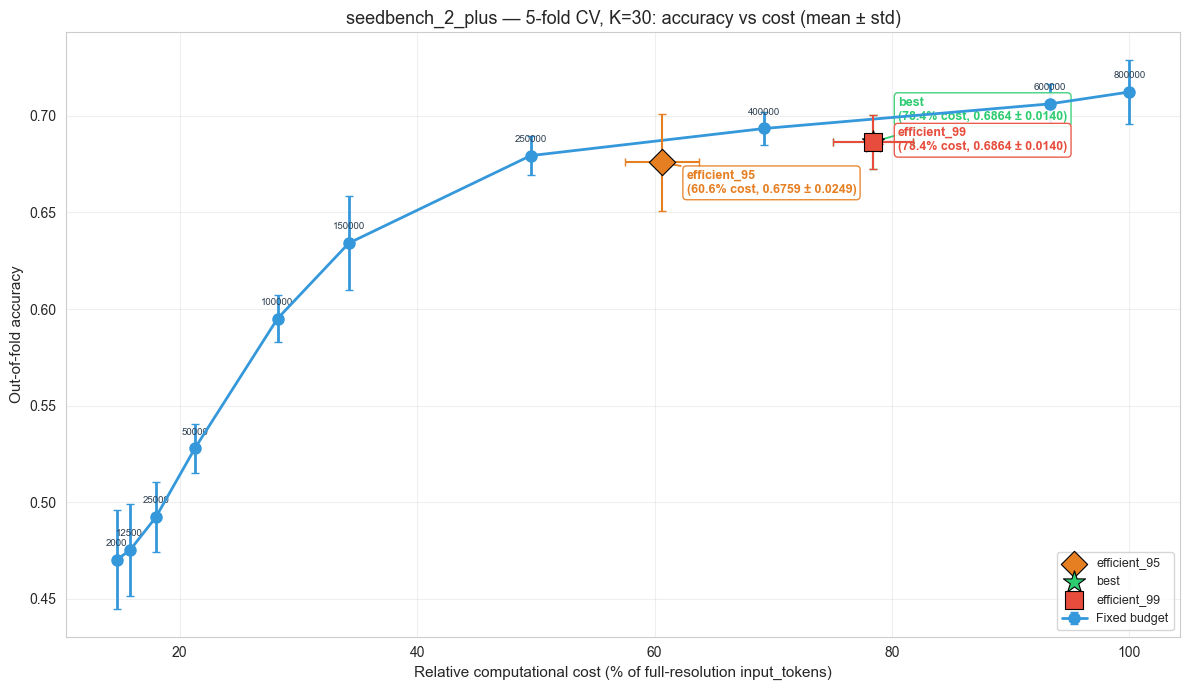

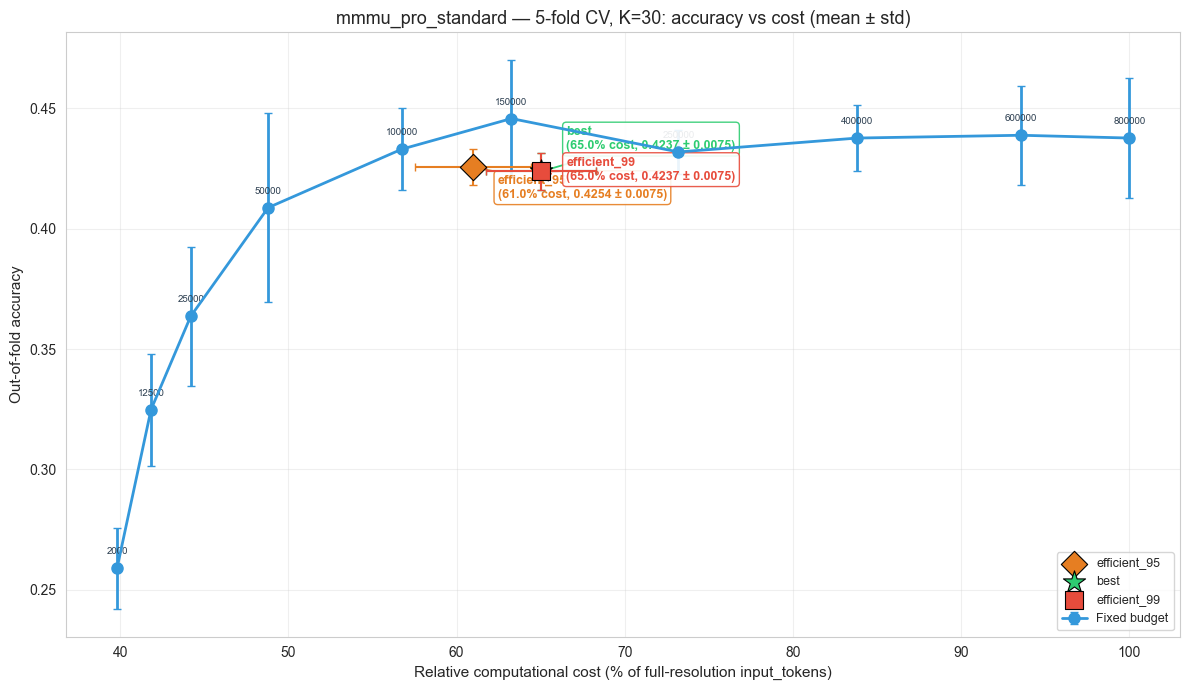

In [8]:
STYLE = {
    "best": ("*", "#2ecc71", 280),
    "efficient_95": ("D", "#e67e22", 180),
    "efficient_99": ("s", "#e74c3c", 180),
}

for label in RUNS:
    table = summaries[label]
    fig, ax = plt.subplots(figsize=(12, 7))

    fixed = table[table["is_fixed"]]
    ax.errorbar(
        fixed["cost_pct"],
        fixed["accuracy"],
        yerr=fixed["accuracy_sd"],
        fmt="o-",
        color="#3498db",
        lw=2,
        ms=8,
        capsize=3,
        label="Fixed budget",
        zorder=3,
    )
    for _, row in fixed.iterrows():
        ax.annotate(
            row["strategy"].replace("fixed_", ""),
            (row["cost_pct"], row["accuracy"]),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=7,
            color="#2c3e50",
        )

    for offset, (_, row) in enumerate(table[~table["is_fixed"]].iterrows()):
        marker, colour, size = STYLE[row["strategy"]]
        ax.errorbar(
            row["cost_pct"],
            row["accuracy"],
            xerr=row["cost_pct_sd"],
            yerr=row["accuracy_sd"],
            fmt="none",
            ecolor=colour,
            capsize=3,
            zorder=4,
        )
        ax.scatter(
            row["cost_pct"],
            row["accuracy"],
            marker=marker,
            c=colour,
            s=size,
            zorder=5,
            edgecolors="black",
            linewidth=0.8,
            label=row["strategy"],
        )
        ax.annotate(
            f"{row['strategy']}\n({row['cost_pct']:.1f}% cost, {row['accuracy']:.4f} ± {row['accuracy_sd']:.4f})",
            (row["cost_pct"], row["accuracy"]),
            textcoords="offset points",
            xytext=(18, (-22, 16, -6)[offset % 3]),
            fontsize=9,
            fontweight="bold",
            color=colour,
            arrowprops=dict(arrowstyle="->", color=colour, lw=1.3),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colour, alpha=0.9),
        )

    ax.set_xlabel(f"Relative computational cost (% of full-resolution {COST})", fontsize=11)
    ax.set_ylabel("Out-of-fold accuracy", fontsize=11)
    ax.set_title(f"{label} — {N_FOLDS}-fold CV, K={SUMMARY_K}: accuracy vs cost (mean ± std)", fontsize=13)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / f"kfold_accuracy_vs_cost_{label}.pdf", bbox_inches="tight")
    plt.show()

---
## 6. Findings

Read the lift column, not the accuracy column. Fill this in from the run:

- is lift positive, and at how many of the K values tested?
- is it larger than the fold-to-fold standard deviation (`accuracy_sd`)?
- does either benchmark behave differently from the other?

A routing policy that only matches the fixed frontier is telling you the useful
signal is *how much resolution the benchmark needs on average*, not *which
question needs what* — in which case the simplest correct action is to pick one
cheaper fixed budget.